In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'sudoku.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img.shape

(563, 558)

In [3]:
thresholds = [80, 127, 180]
global_masks = [cv2.threshold(img, t, 255, cv2.THRESH_BINARY)[1] for t in thresholds]
adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)

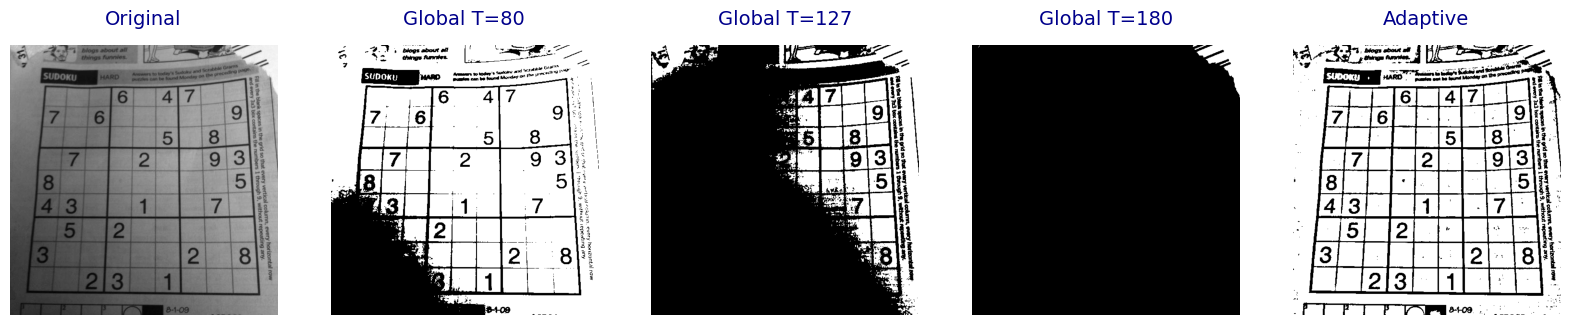

In [4]:
panels = [('Original', img)]
panels += [(f'Global T={t}', m) for t, m in zip(thresholds, global_masks)]
panels += [('Adaptive', adaptive)]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
N, M = img.shape
for title, m in panels[1:]:
    print(title, '- black pixels left:', round(np.mean(m[:, :M // 2] == 0), 3), 'right:', round(np.mean(m[:, M // 2:] == 0), 3))

Global T=80 - black pixels left: 0.408 right: 0.108
Global T=127 - black pixels left: 0.968 right: 0.526
Global T=180 - black pixels left: 1.0 right: 0.976
Adaptive - black pixels left: 0.185 right: 0.204


In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task1_adaptive.png', adaptive)

True

Global thresholding fails in the bottom-left of the page, which is in shadow. T=80 blackens that corner but the rest is readable. T=127 and T=180 blacken most of the page since even the paper there is darker than T. T=80 is the best global one but still loses the digits in the shadow.

The adaptive result uses Gaussian, blockSize=51, C=5 (from Task 2). The block covers a digit plus some paper around it and C=5 removes the paper texture.

Why does a single threshold struggle when illumination changes? The same number is used for every pixel but the paper itself is brighter in some places than others. In the dark part the paper falls below the threshold, in the bright part the ink can go above it. Adaptive uses the local neighbourhood so the lighting difference cancels out.